### Clustering of fashion items from the FashionMNIST dataset 
Details: FashionMNIST dataset consists of 60000 fashion items, each of which coming as a 28 x 28 grayscale image. For the purpose of limiting computations, I consider a subset of 1000 instances from this dataset, and thus, extract a dataset of size 1000 x 784 (the 784 dimensions correspond to representing images as a flat vector). I also generate a PCA representation of the data for visualization purposes.

In [16]:
import numpy as np
import scipy
import sklearn
import sklearn.datasets
import sklearn.decomposition
import torchvision
import matplotlib
import utils
from matplotlib import pyplot as plt
lcm = matplotlib.colors.ListedColormap

In [17]:
X = torchvision.datasets.FashionMNIST('.',download=True).data.numpy()

np.random.seed(0)
R = np.random.permutation(len(X))[:1000]
X = X[R].reshape(-1,784)

X = X / 255.0

Z = sklearn.decomposition.PCA(n_components=2).fit_transform(X)

The first 50 images of our dataset are visualized below:

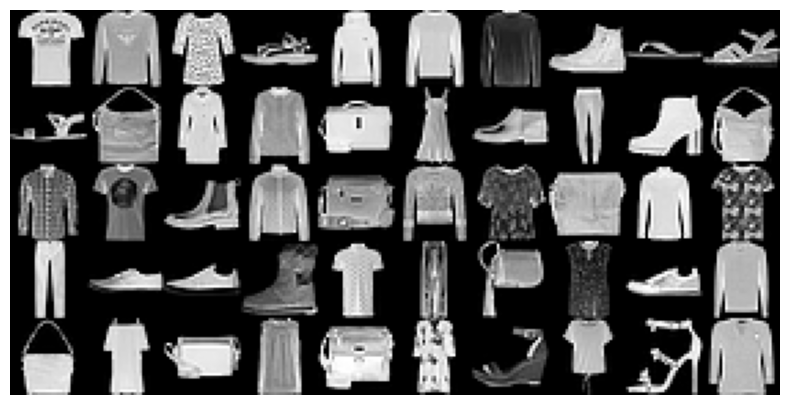

In [10]:
plt.figure(figsize=(10,5))
plt.axis('off')
plt.imshow(X[:50].reshape(5,10,28,28).transpose(0,2,1,3).reshape(5*28,10*28),cmap='gray',vmin=0,vmax=1)
plt.show()

Rudimentary version of **K-Means**, where the cluster centers are initialized to the first few examples of the dataset, and where the number of iterations is fixed to 100.

In [18]:
class KMeans:
    
    def __init__(self,n_clusters):
        self.n_clusters = n_clusters
        self.cluster_centers = None

    def fit(self,X):
        cluster_list = None
        X = tuple(X)

        for iteration in range(100):
            if iteration == 0:
                self.cluster_centers = list(X[i] for i in range(self.n_clusters))

            cluster_list = [[] for _ in range(self.n_clusters)]
            centroid_dist = []

            for datapoint in X:
                centroid_dist = []
                for j in range(self.n_clusters):
                    centroid_dist.append(np.linalg.norm(datapoint-self.cluster_centers[j]))
                centroid_ind = np.argmin(centroid_dist)
                cluster_list[centroid_ind].append(datapoint)                   

            for i in range(len(self.cluster_centers)):
                elem_sum = sum(cluster_list[i])
                if len(cluster_list[i]) != 0:
                    self.cluster_centers[i] = 1/(len(cluster_list[i])) * elem_sum
                
       

    def predict(self,X):
        
        D = scipy.spatial.distance.cdist(X,self.cluster_centers)
        return numpy.argmin(D,axis=1)
    
    def cluster_centers(self):
        return self.cluster_centers
                
    
model = KMeans(20)
model.fit(X)

The outcome of the clustering procedure visualized in the following PCA plot color-coded by cluster membership.

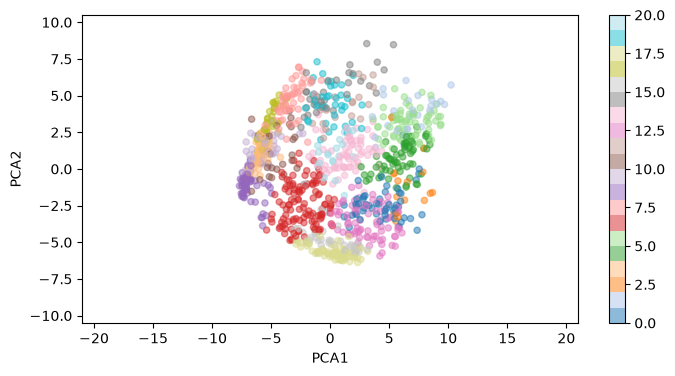

In [19]:
np.random.seed(0)
Y = model.predict(X)

utils.preparefigure(7)
plt.scatter(*Z.T,c=Y,s=20,vmin=0,vmax=20,cmap='tab20',alpha=0.5)
plt.colorbar()

What are prototypical fashion items in the dataset. For this, I consider the cluster centers learned by k-means.

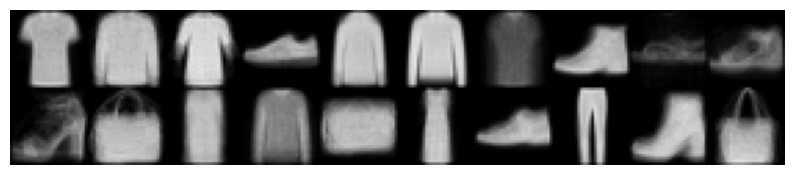

In [20]:
centroids = model.cluster_centers
centroids_np = np.asarray(centroids)
plt.figure(figsize=(10,20))
plt.axis('off')
plt.imshow(centroids_np.reshape(2,10,28,28).transpose(0,2,1,3).reshape(2*28,10*28),cmap='gray',vmin=0,vmax=1)
#plt.imshow(centroids_np,cmap='gray')
plt.show()

How well do these cluster centers describe our data. Computed total variance, the within-cluster variance, the between-cluster variance, and the percentage of explained variance.

In [31]:
def analyze_variance(X,model):
    X = np.asarray(X)
    Y = model.predict(X)
    Y = np.asarray(Y).astype(int).ravel()
    centers = np.asarray(model.cluster_centers) 
    var_tot = np.var(X,axis=0).sum()
    var_between = np.var(X*0 + centers[Y],axis=0).sum()
    var_within = np.var(X - centers[Y],axis=0).sum()
    var_expl_f = var_between / var_tot
    print(f"Total variance {var_tot:8.3f}")
    print(f"Between-cluster variance {var_between:8.3f}")
    print(f"Within-cluster variance {var_within:8.3f}")
    print('')
    print(f"Explained variance (%) {var_expl_f*100:7.2f}%")
analyze_variance(X,model)


Total variance   68.120
Between-cluster variance   41.579
Within-cluster variance   26.541

Explained variance (%)   61.04%


A bit more than half of the variance in the data is captured by the clustering, which is quite good, considering that the data is high-dimensional.